# Lotto Exploratory Data Analysis (EDA)

This notebook visually inspects the historical lotto dataset.

The goal is not only to check simple frequencies, but also to see whether the real data looks materially different from a uniform process, whether there are visible time trends, and whether strong dependence appears between numbers.

Topics covered:

1. Main-number frequency vs. uniform expectation
2. Bonus-number frequency vs. uniform expectation
3. Odd-even distribution
4. Low-high distribution
5. Distribution of the number sum
6. Time-trend inspection
7. Pairwise correlation inspection

### 1. Library Imports

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
APP_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "src" / "notebook_support.py").exists() and (candidate / "data").exists():
        APP_ROOT = candidate
        break
    if (candidate / "app" / "src" / "notebook_support.py").exists() and (candidate / "app" / "data").exists():
        APP_ROOT = candidate / "app"
        break

if APP_ROOT is None:
    raise RuntimeError(f"Could not locate app root from {cwd}")

if str(APP_ROOT) not in sys.path:
    sys.path.insert(0, str(APP_ROOT))

from src.notebook_support import describe_notebook_environment
describe_notebook_environment(APP_ROOT)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis import (
    build_one_hot_matrix,
    build_upper_triangle_mask,
    calculate_bonus_frequency,
    calculate_correlation_matrix,
    calculate_expected_bonus_frequency,
    calculate_expected_main_frequency,
    calculate_low_high_distribution,
    calculate_number_frequency,
    calculate_odd_even_distribution,
    calculate_round_sum_trend,
    calculate_sum_distribution,
    categorize_number_ranges,
)
from src.config import PROCESSED_LOTTO_FILE
from src.visualization import (
    plot_bonus_number_frequency,
    plot_correlation_heatmap,
    plot_count_distribution,
    plot_main_number_frequency,
    plot_sum_distribution,
    plot_sum_over_time,
)
from src.visualization import save_report_figure, save_report_table


In [2]:
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

### 2. Load the Data

In [3]:
df = pd.read_csv(PROCESSED_LOTTO_FILE)
df.head()

,row_id,round,n1,n2,n3,n4,n5,n6,bonus,rank_text,winner_count,prize_amount,numbers,sum_main,odd_count,even_count,low_count,high_count
0,1214,1,10,23,29,33,37,40,16,1등,0,0,"10,23,29,33,37,40",172,4,2,1,5
1,1213,2,9,13,21,25,32,42,2,1등,1,2002006800,"9,13,21,25,32,42",142,4,2,3,3
2,1212,3,11,16,19,21,27,31,30,1등,1,2000000000,"11,16,19,21,27,31",125,5,1,4,2
3,1211,4,14,27,30,31,40,42,2,1등,0,0,"14,27,30,31,40,42",184,2,4,1,5
4,1210,5,16,24,29,40,41,42,3,1등,0,0,"16,24,29,40,41,42",192,2,4,1,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1222 entries, 0 to 1221
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   row_id        1222 non-null   int64 
 1   round         1222 non-null   int64 
 2   n1            1222 non-null   int64 
 3   n2            1222 non-null   int64 
 4   n3            1222 non-null   int64 
 5   n4            1222 non-null   int64 
 6   n5            1222 non-null   int64 
 7   n6            1222 non-null   int64 
 8   bonus         1222 non-null   int64 
 9   rank_text     1222 non-null   object
 10  winner_count  1222 non-null   int64 
 11  prize_amount  1222 non-null   int64 
 12  numbers       1222 non-null   object
 13  sum_main      1222 non-null   int64 
 14  odd_count     1222 non-null   int64 
 15  even_count    1222 non-null   int64 
 16  low_count     1222 non-null   int64 
 17  high_count    1222 non-null   int64 
dtypes: int64(16), object(2)
memory usage: 172.0+ KB


In [5]:
df.describe()

,row_id,round,n1,n2,n3,n4,n5,n6,bonus,winner_count,prize_amount,sum_main,odd_count,even_count,low_count,high_count
count,1222.000000,1222.000000,1222.000000,1222.000000,1222.000000,1222.000000,1222.000000,1222.000000,1222.000000,1222.000000,1.222000e+03,1222.000000,1222.000000,1222.000000,1222.000000,1222.000000
mean,611.500000,611.500000,6.731588,13.076923,19.930442,26.216039,32.838789,39.432079,22.351882,8.478723,2.636386e+09,138.225859,3.073650,2.926350,2.941899,3.058101
std,352.905323,352.905323,5.402699,6.883777,7.395745,7.517981,6.810963,5.325434,13.155614,5.157388,2.346303e+09,30.788540,1.153768,1.153768,1.178178,1.178178
min,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,9.000000,17.000000,1.000000,0.000000,0.000000e+00,48.000000,0.000000,0.000000,0.000000,0.000000
25%,306.250000,306.250000,3.000000,8.000000,14.000000,21.000000,28.000000,37.000000,11.000000,5.000000,1.571570e+09,116.250000,2.000000,2.000000,2.000000,2.000000
50%,611.500000,611.500000,5.000000,12.000000,19.000000,27.000000,34.000000,41.000000,23.000000,8.000000,2.078125e+09,137.500000,3.000000,3.000000,3.000000,3.000000
75%,916.750000,916.750000,10.000000,17.000000,25.000000,32.000000,38.000000,44.000000,33.000000,11.000000,2.953716e+09,160.000000,4.000000,4.000000,4.000000,4.000000
max,1222.000000,1222.000000,35.000000,37.000000,40.000000,43.000000,44.000000,45.000000,45.000000,63.000000,4.072296e+10,238.000000,6.000000,6.000000,6.000000,6.000000


In [6]:
df["round"].min(), df["round"].max()

(np.int64(1), np.int64(1222))

### 3. Main-Number Frequency

This section checks how often each main number appeared over the full history.
The red dashed line shows the expected frequency under a perfectly uniform process.

In [7]:
number_cols = ["n1", "n2", "n3", "n4", "n5", "n6"]
bonus_col = "bonus"

In [8]:
number_freq = calculate_number_frequency(df, number_cols=number_cols)
number_freq

1     168
2     154
3     171
4     160
5     153
6     164
7     168
8     156
9     133
10    161
11    165
12    177
13    176
14    170
15    167
16    166
17    170
18    173
19    167
20    168
21    165
22    143
23    147
24    164
25    151
26    164
27    180
28    155
29    153
30    157
31    166
32    143
33    173
34    182
35    161
36    163
37    171
38    169
39    166
40    172
41    148
42    154
43    163
44    161
45    174
Name: count, dtype: int64

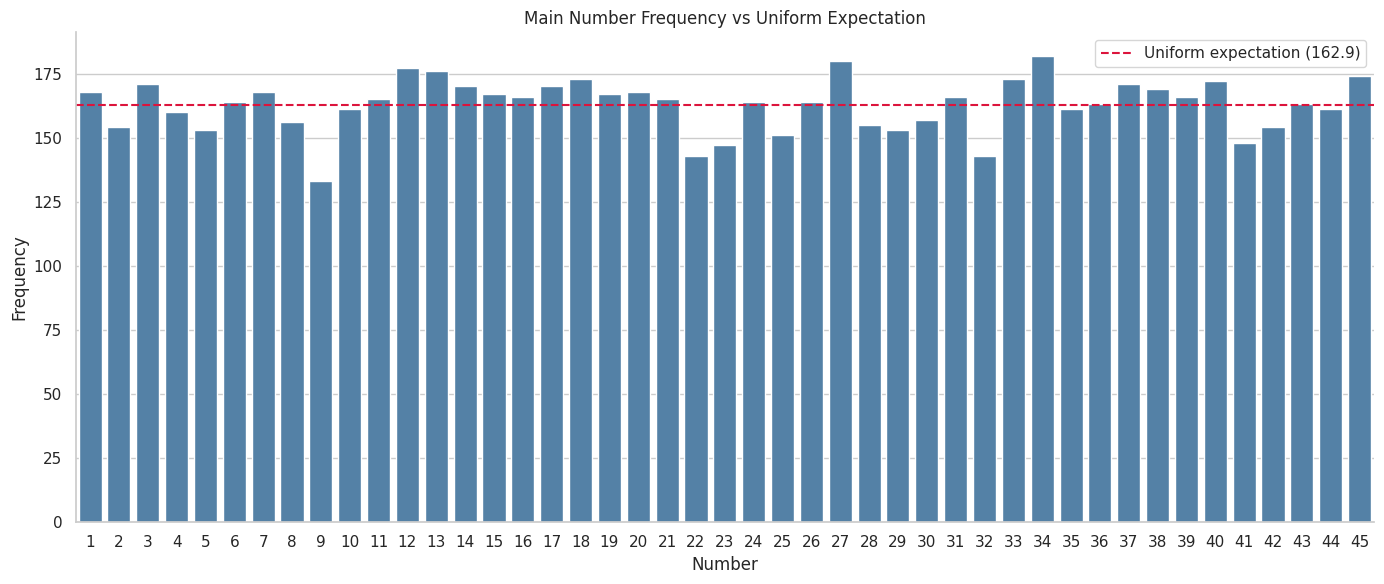

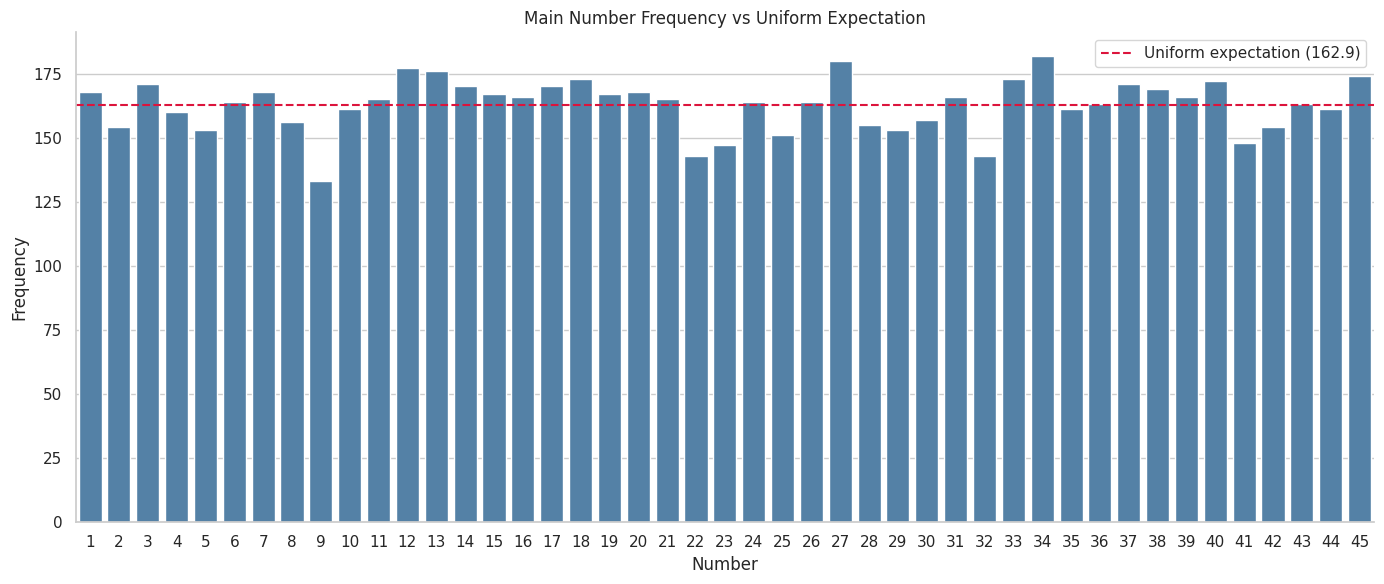

In [9]:
expected_freq = calculate_expected_main_frequency(df)
plot_main_number_frequency(number_freq, expected_freq)

### 4. Bonus-Number Frequency

This section checks whether bonus numbers also show any long-run concentration on specific values.

In [10]:
bonus_freq = calculate_bonus_frequency(df, bonus_col=bonus_col)
bonus_freq

bonus
1     32
2     36
3     31
4     35
5     25
6     34
7     32
8     24
9     26
10    28
11    26
12    27
13    27
14    23
15    25
16    29
17    33
18    19
19    22
20    29
21    25
22    20
23    21
24    33
25    23
26    31
27    31
28    25
29    17
30    32
31    32
32    34
33    31
34    24
35    30
36    24
37    26
38    30
39    25
40    22
41    18
42    25
43    35
44    24
45    21
Name: count, dtype: int64

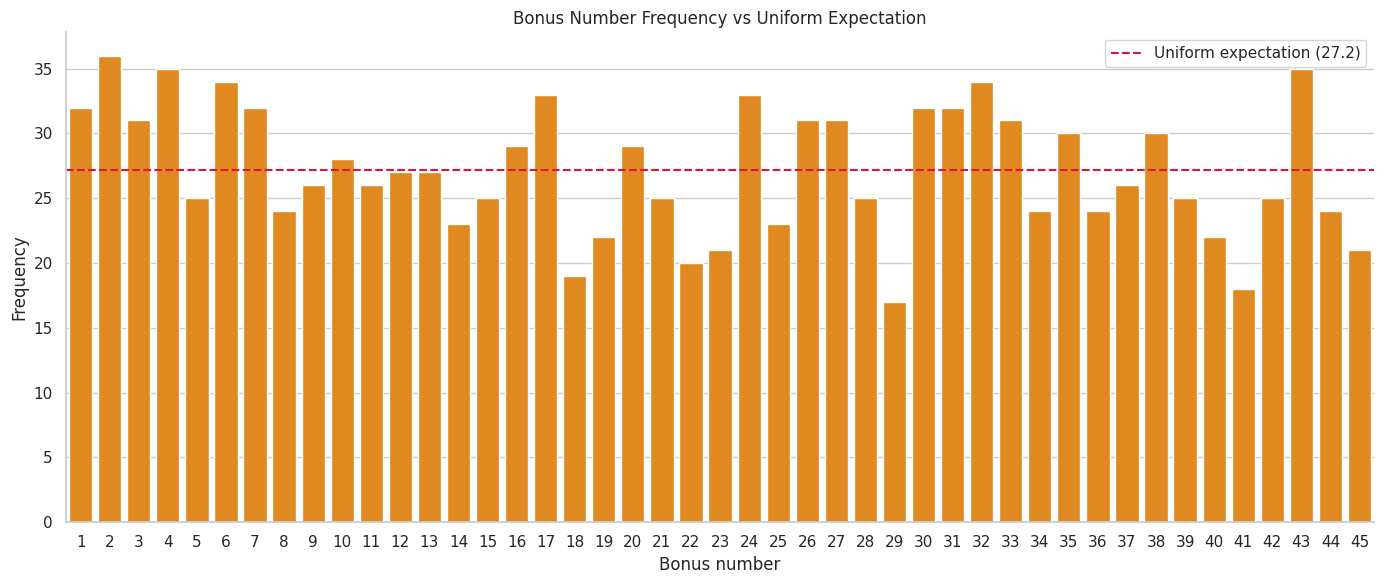

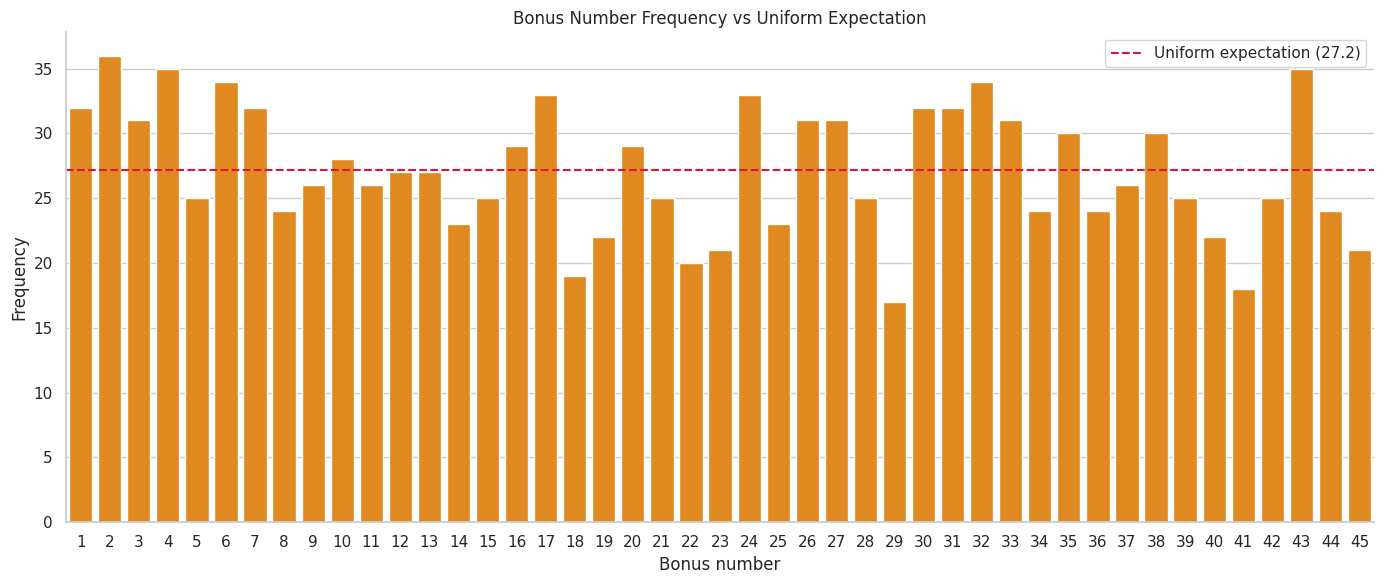

In [11]:
expected_bonus_freq = calculate_expected_bonus_frequency(df)
plot_bonus_number_frequency(bonus_freq, expected_bonus_freq)

### 5. Odd-Even Pattern

In [12]:
calculate_odd_even_distribution(df)

odd_count
0     17
1     82
2    271
3    410
4    326
5     98
6     18
Name: count, dtype: int64

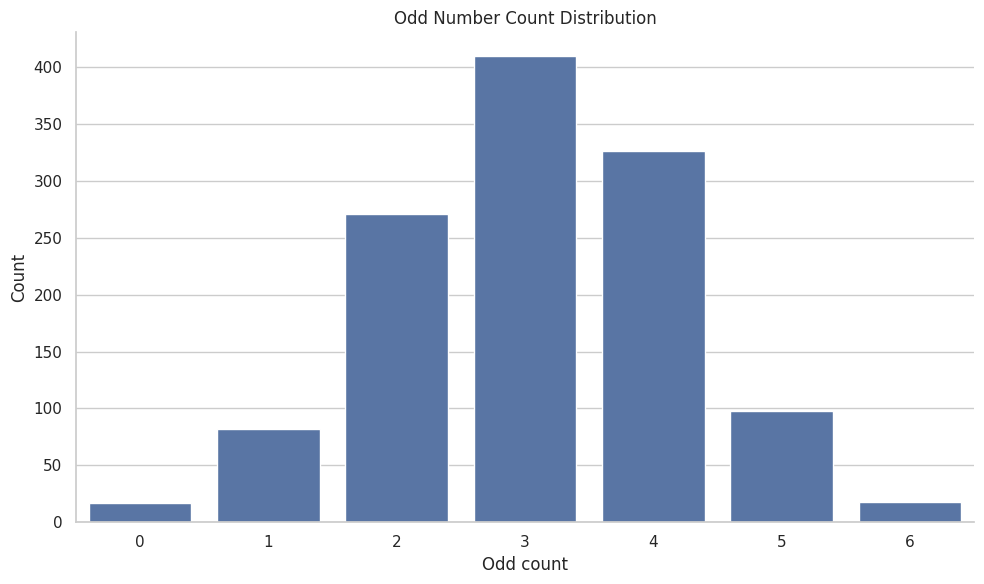

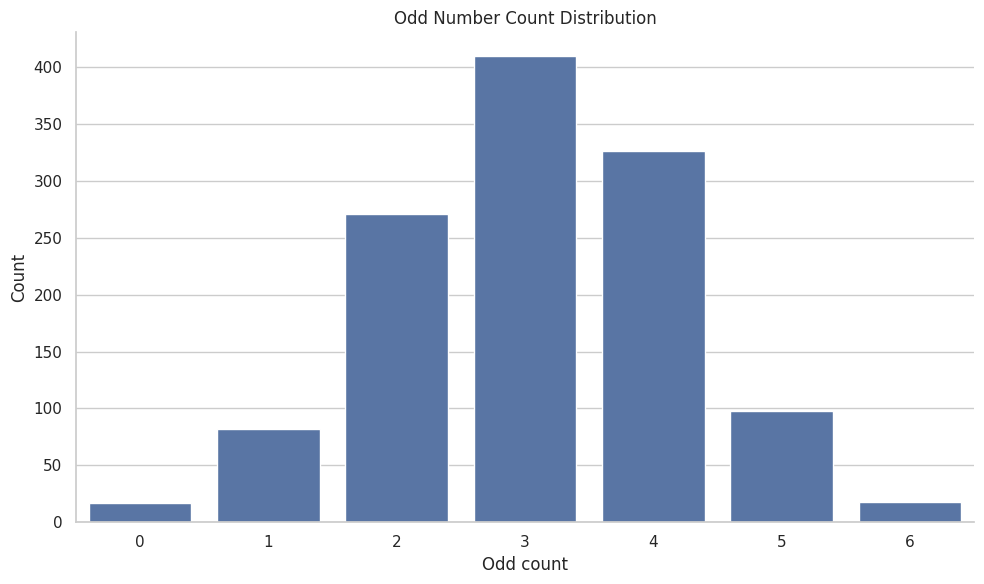

In [13]:
plot_count_distribution(df["odd_count"], title="Odd Number Count Distribution", xlabel="Odd count")

### 6. Low-High Split

- Low: 1-22
- High: 23-45

In [14]:
calculate_low_high_distribution(df)

low_count
0     16
1    113
2    308
3    400
4    275
5     94
6     16
Name: count, dtype: int64

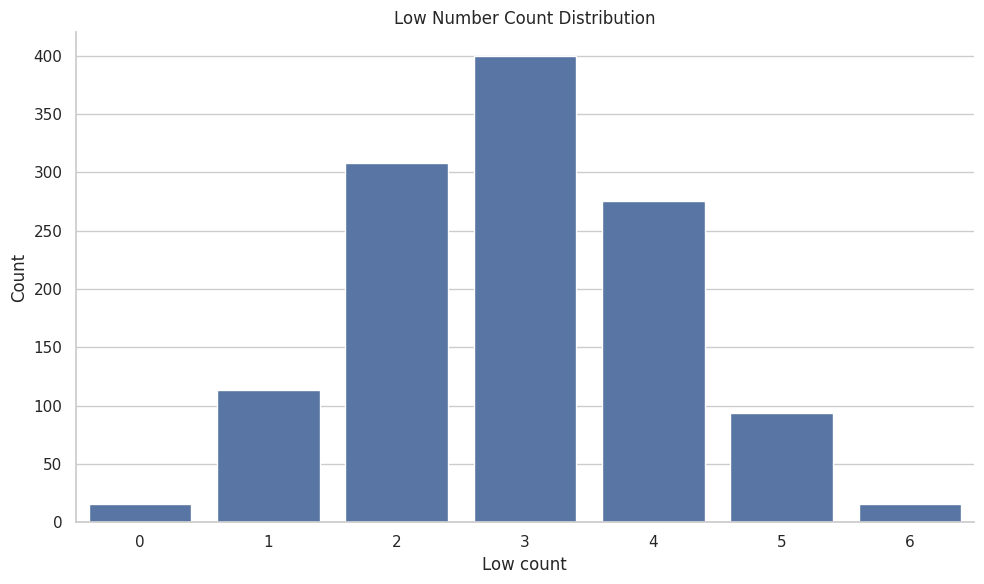

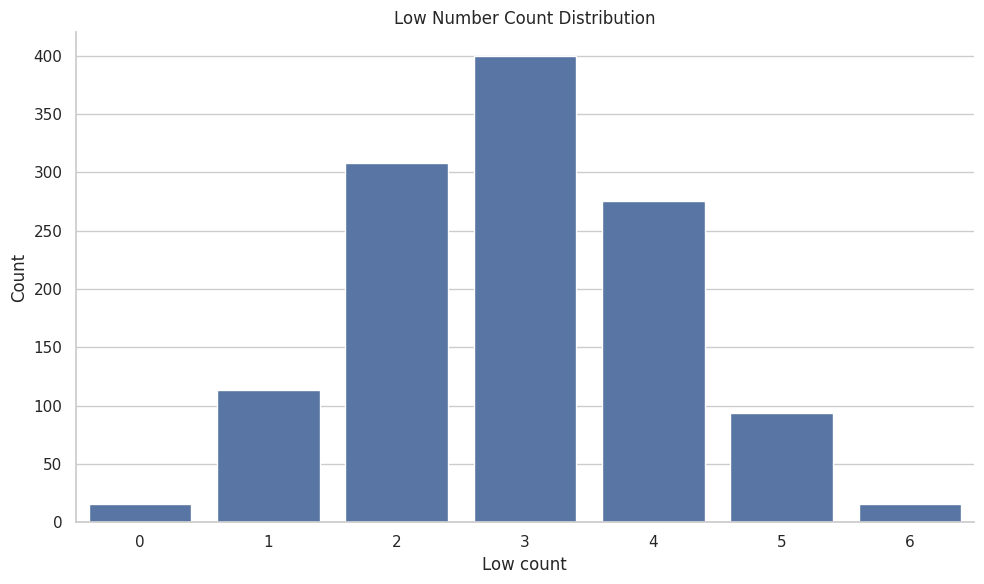

In [15]:
plot_count_distribution(df["low_count"], title="Low Number Count Distribution", xlabel="Low count")

### 7. Sum Distribution

This section looks at the range where the sum of the six main numbers usually falls.
A KDE curve and the mean line are added to make the center and spread easier to interpret.

In [16]:
calculate_sum_distribution(df).describe()

count    1222.000000
mean      138.225859
std        30.788540
min        48.000000
25%       116.250000
50%       137.500000
75%       160.000000
max       238.000000
Name: sum_main, dtype: float64

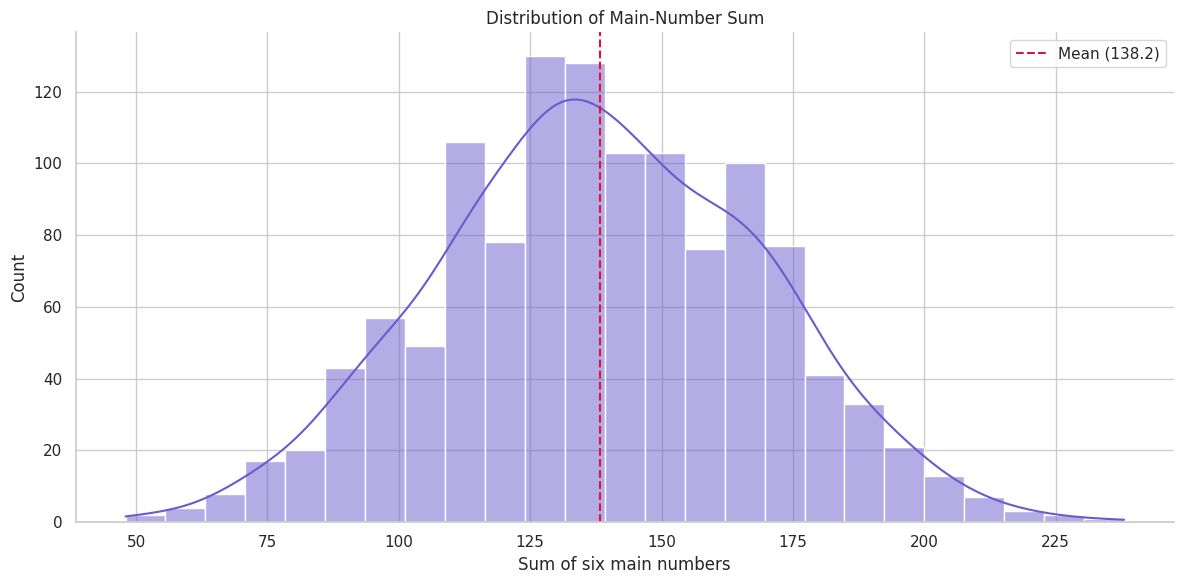

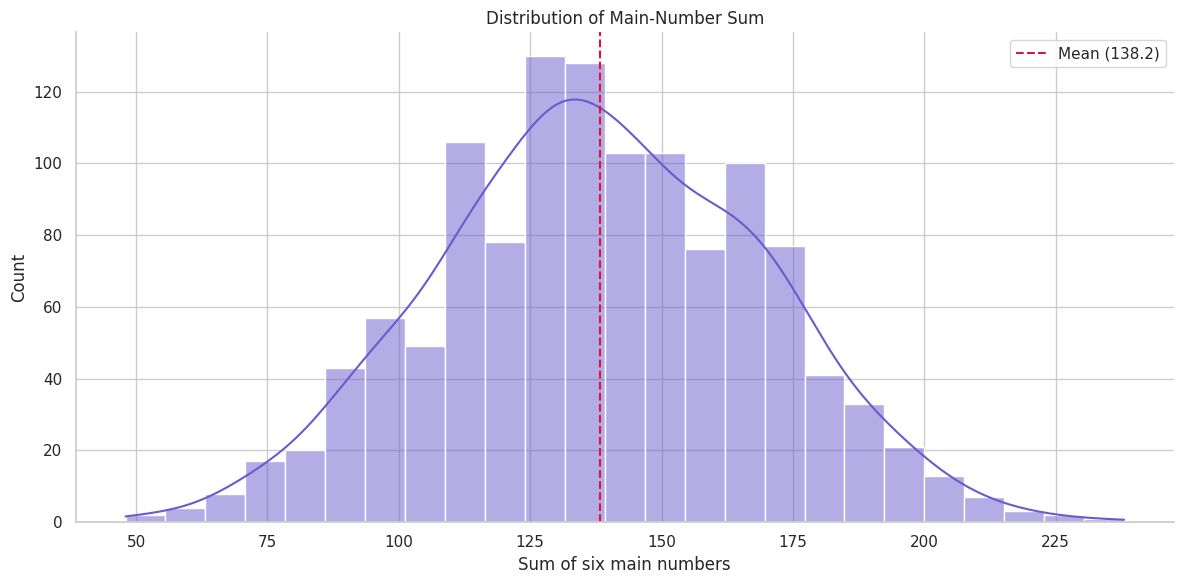

In [17]:
plot_sum_distribution(calculate_sum_distribution(df))

### 8. Time-Trend Inspection

This section checks whether the sum of the main numbers shows any structural trend over time.
It plots individual rounds together with a 20-round rolling mean to make long-run drift easier to see.

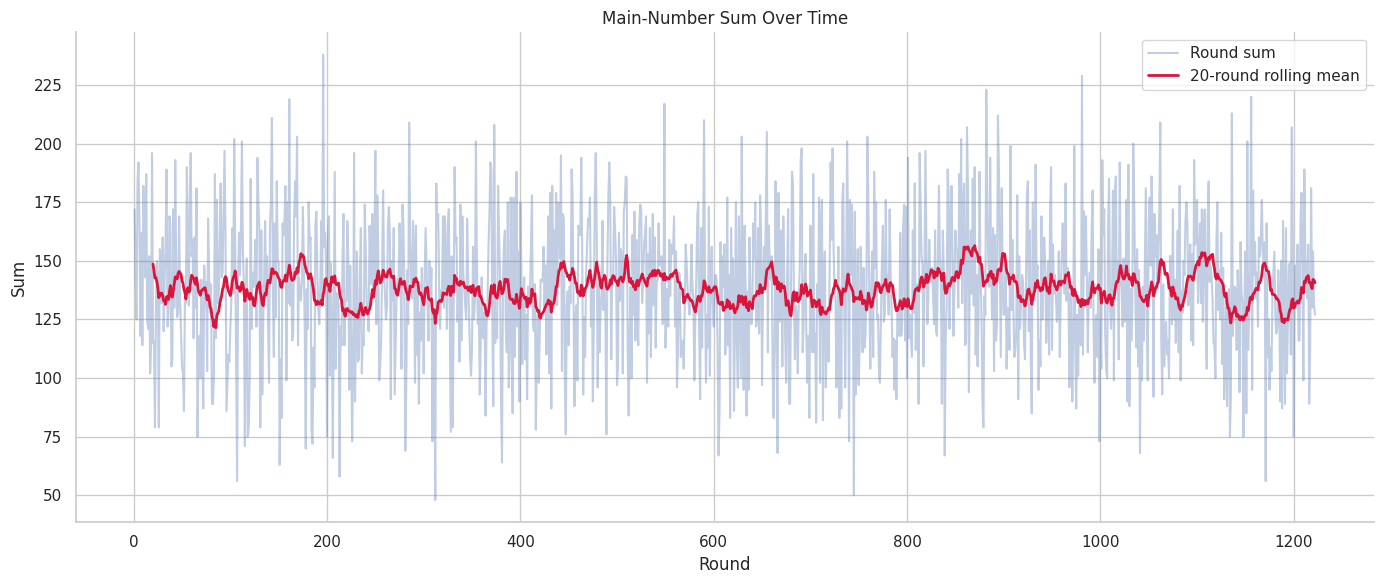

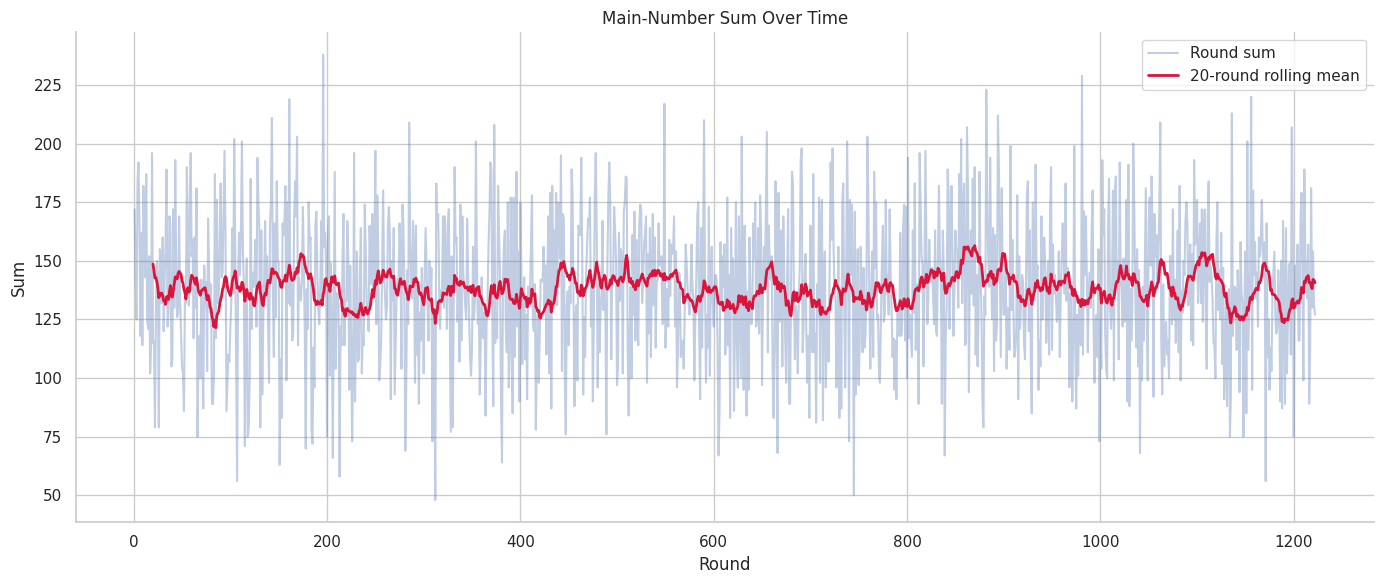

In [18]:
sum_trend = calculate_round_sum_trend(df)
rolling_sum = sum_trend["sum_main"].rolling(20).mean()
plot_sum_over_time(sum_trend["round"], sum_trend["sum_main"], rolling_sum)

### 9. Number-Appearance Heatmap

In [19]:
one_hot = build_one_hot_matrix(df, number_cols=number_cols)

In [20]:
one_hot.sum()

1     168
2     154
3     171
4     160
5     153
6     164
7     168
8     156
9     133
10    161
11    165
12    177
13    176
14    170
15    167
16    166
17    170
18    173
19    167
20    168
21    165
22    143
23    147
24    164
25    151
26    164
27    180
28    155
29    153
30    157
31    166
32    143
33    173
34    182
35    161
36    163
37    171
38    169
39    166
40    172
41    148
42    154
43    163
44    161
45    174
dtype: int64

### 10. Pairwise Correlation

This heatmap shows pairwise correlations among one-hot encoded numbers.
If strong positive or negative correlations are mostly absent, it supports the interpretation that dependence across numbers is limited.

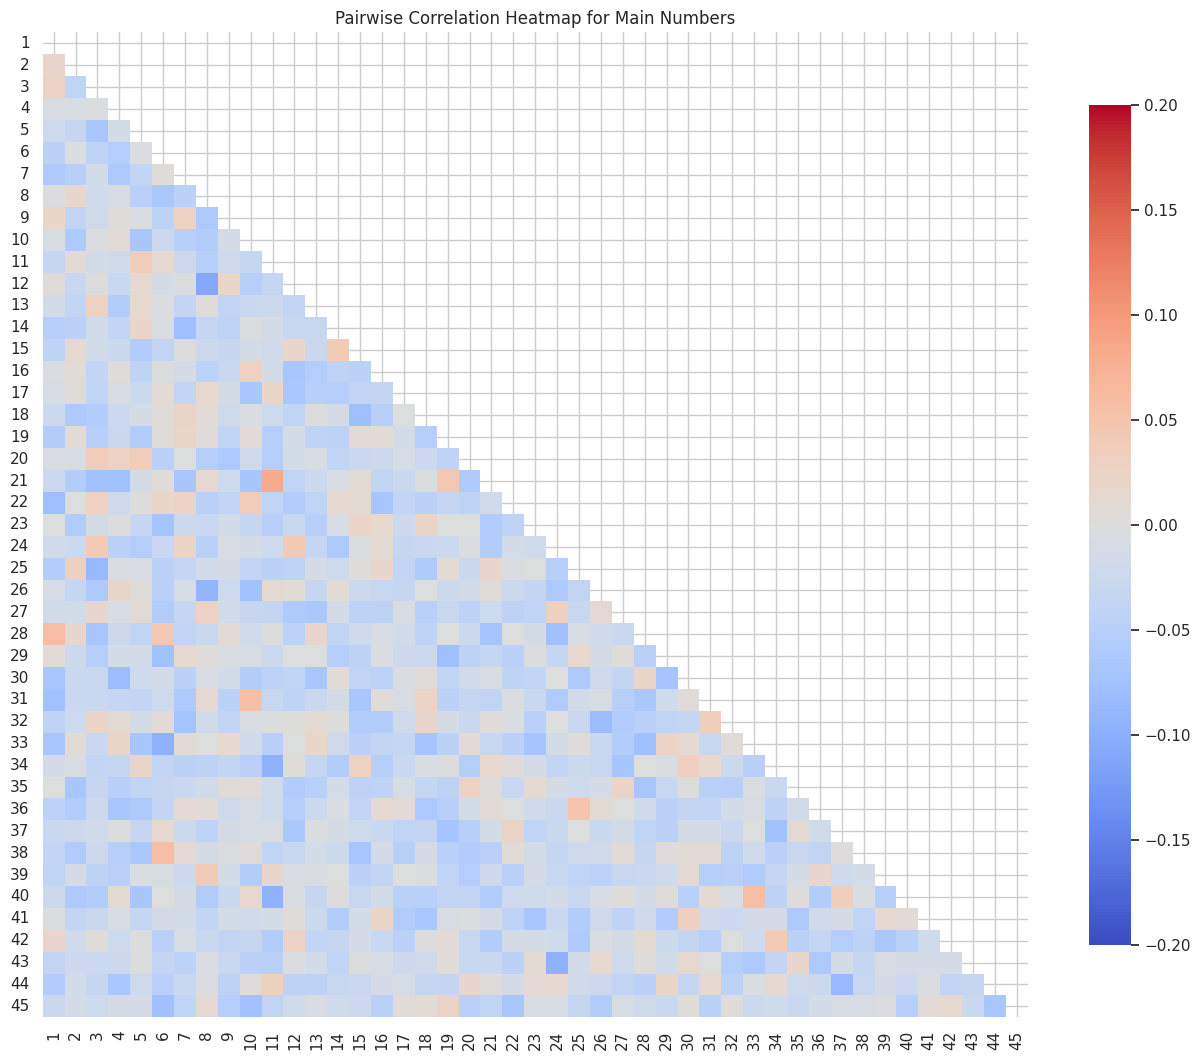

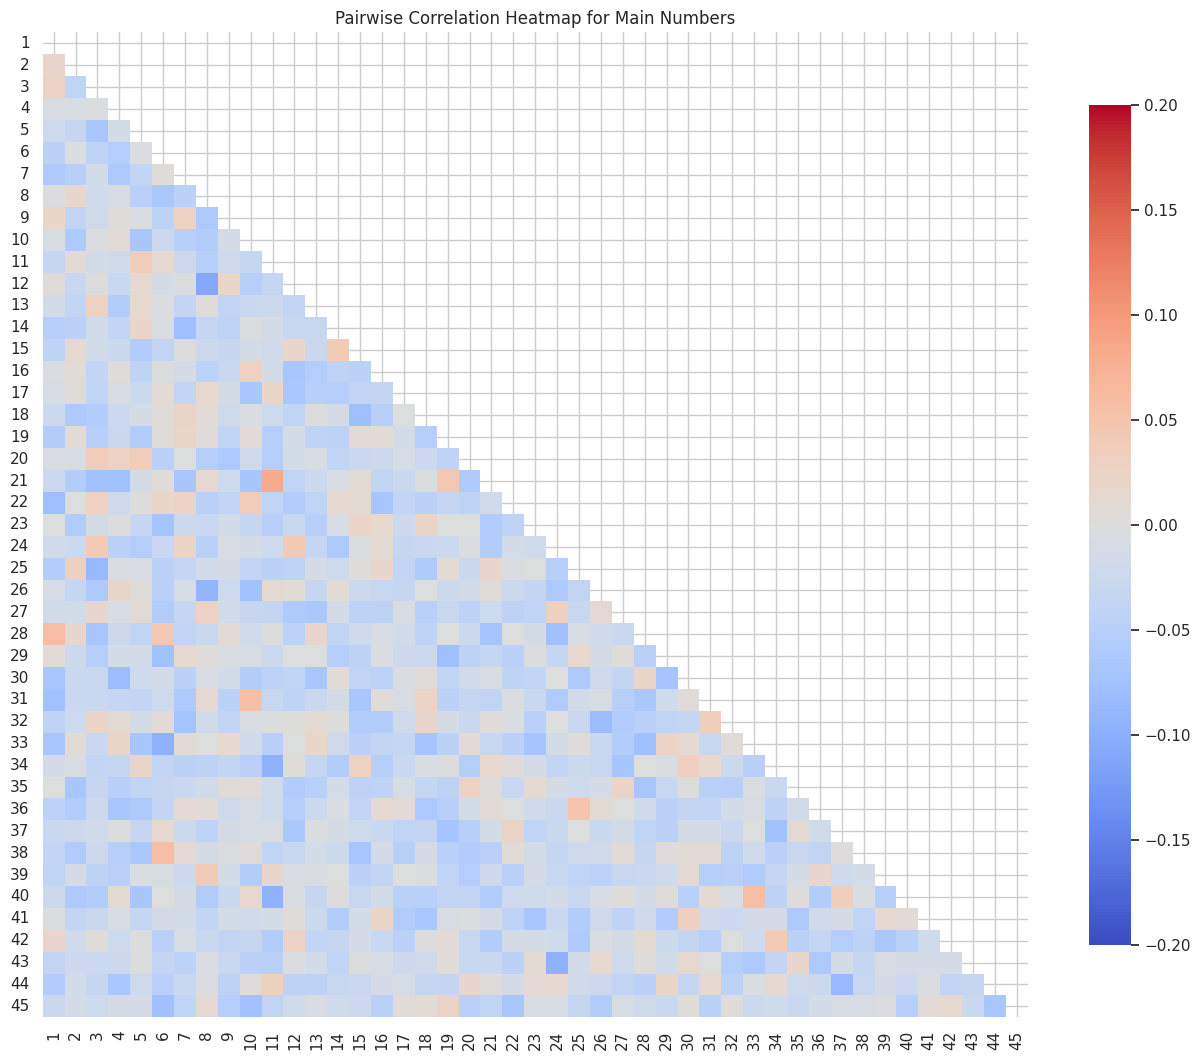

In [21]:
corr = calculate_correlation_matrix(one_hot)
mask = build_upper_triangle_mask(corr)
plot_correlation_heatmap(corr, mask=mask)

### 11. Appearance Counts

In [22]:
# 최댓값 10개
number_freq.sort_values(ascending=False).head(10)

34    182
27    180
12    177
13    176
45    174
18    173
33    173
40    172
37    171
3     171
Name: count, dtype: int64

In [23]:
# 최솟값 10개
number_freq.sort_values().head(10)

9     133
22    143
32    143
23    147
41    148
25    151
29    153
5     153
42    154
2     154
Name: count, dtype: int64

### 12. Range-Based Distribution

In [24]:
binned = categorize_number_ranges(df, number_cols=number_cols)
pd.Series(binned).value_counts()

11-20    1699
31-40    1666
1-10     1588
21-30    1579
41-45     800
Name: count, dtype: int64

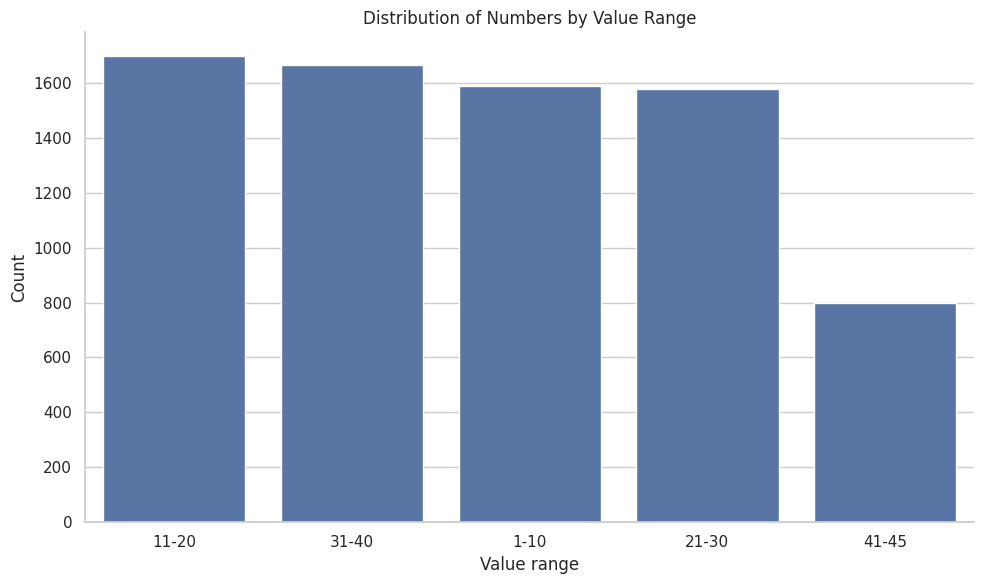

In [25]:
plt.figure(figsize=(10,6))
sns.countplot(x=binned, order=binned.value_counts().index)
plt.title("Distribution of Numbers by Value Range")
plt.xlabel("Value range")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 13. EDA Summary

The purpose of this stage is to gather visual evidence for the following questions:

- Do some numbers appear far more or less often than expected over the long run?
- Do the sum, odd-even mix, or range-based counts show structural bias?
- Is there any visible long-run drift over time?
- Are strong correlations visible between numbers?

The next notebook tests these observations more rigorously with statistical tests and random simulations.

### Report Export


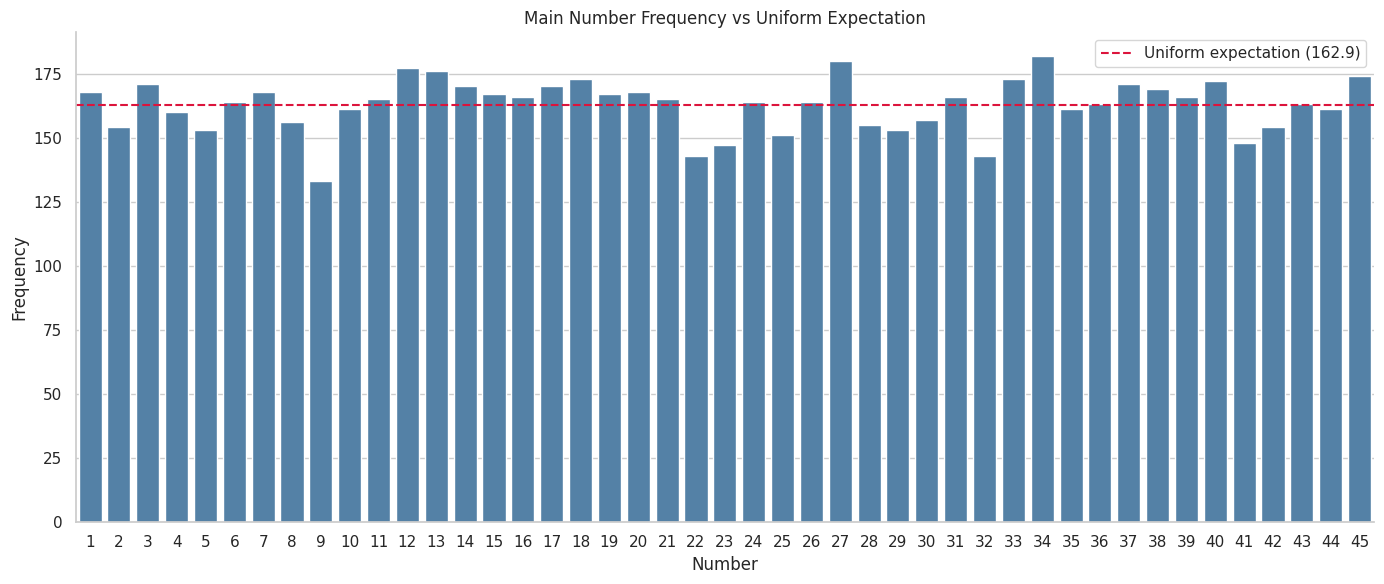

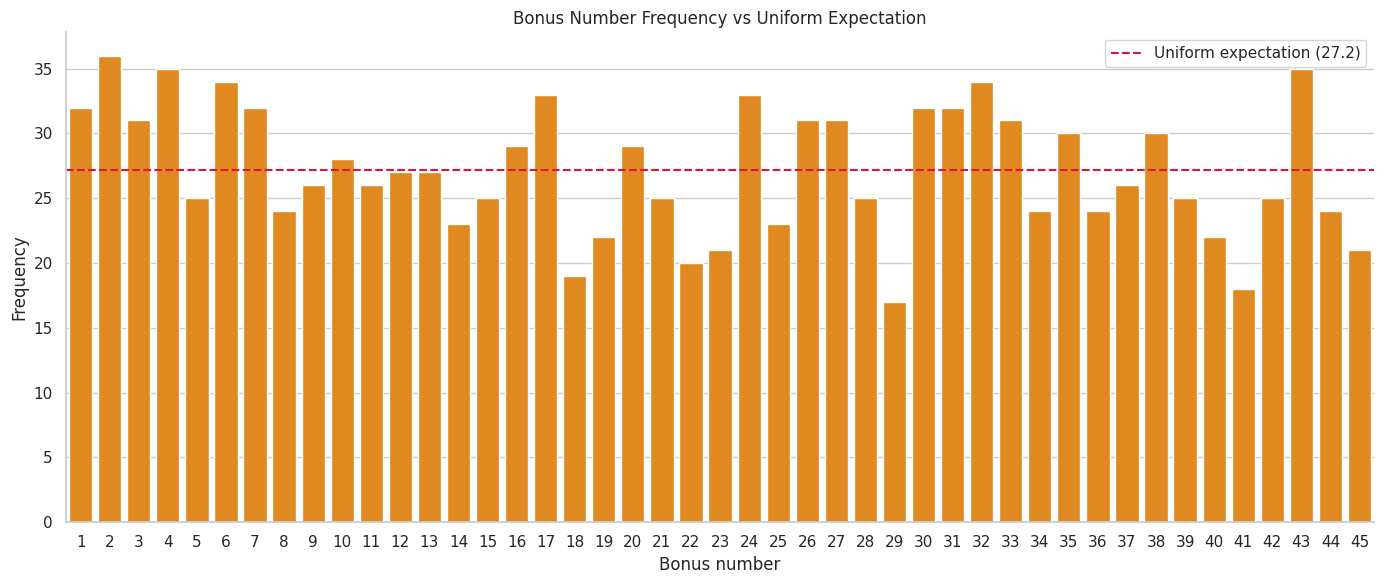

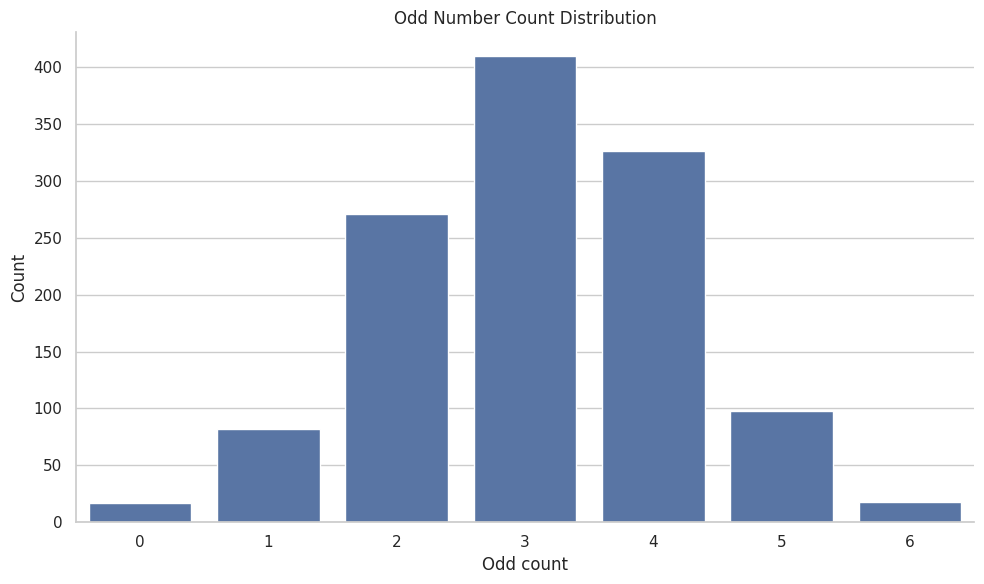

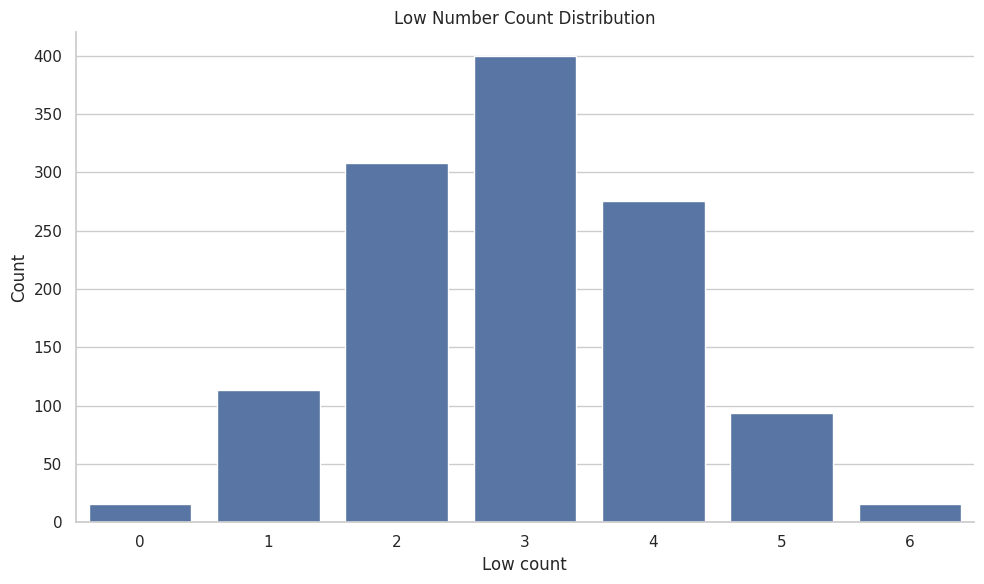

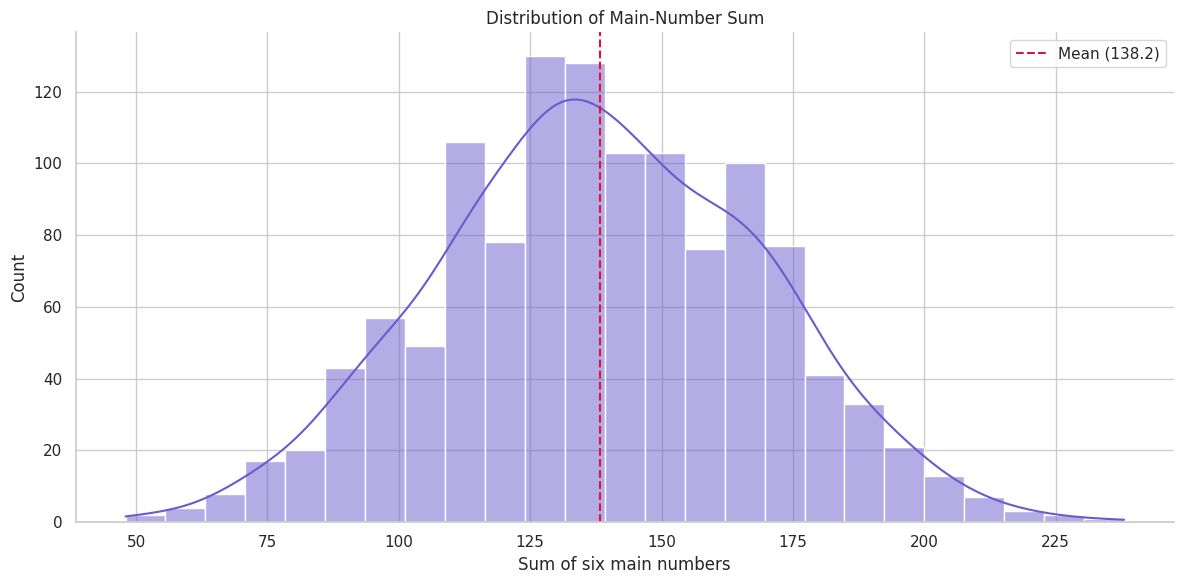

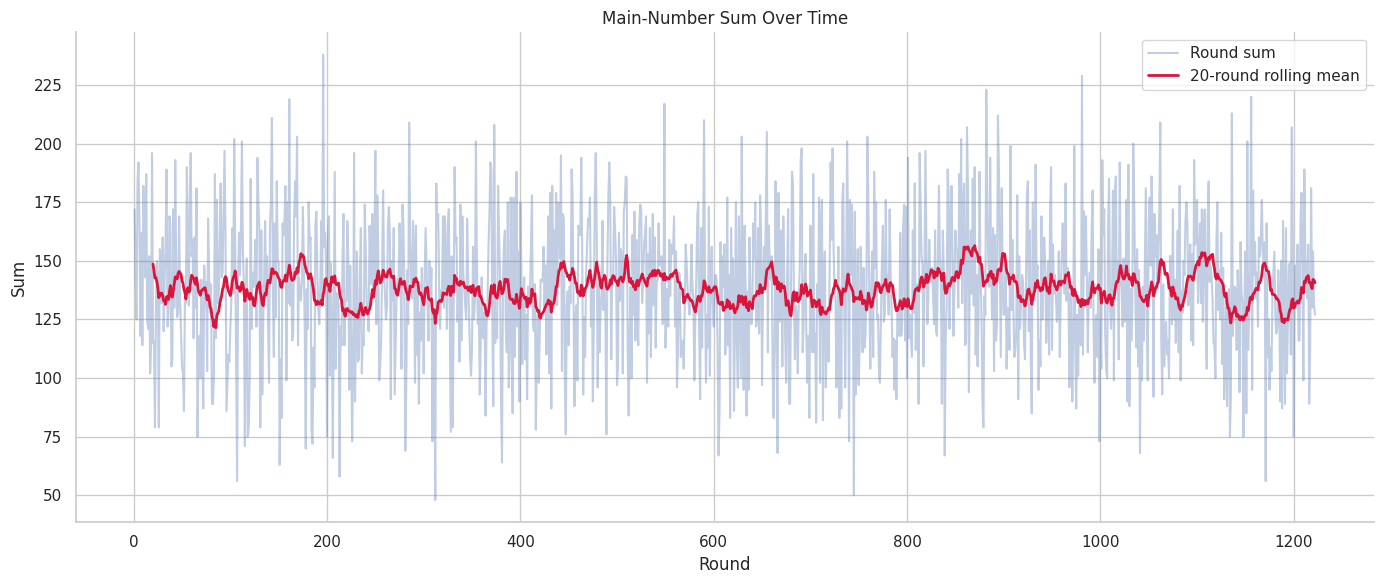

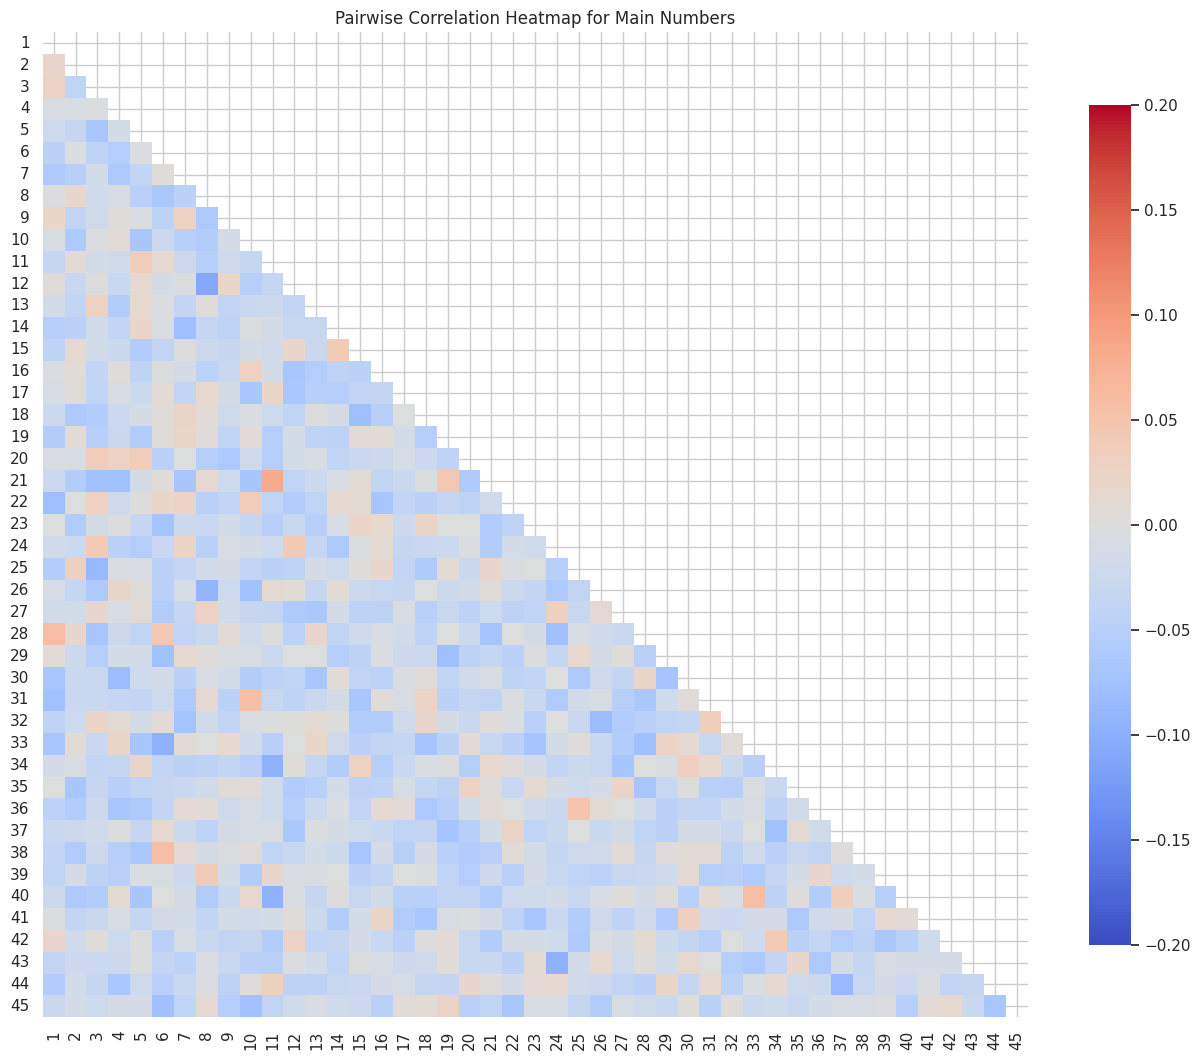

Saved EDA report artifacts.


In [26]:
# Save final EDA figures and tables for the report
fig = plot_main_number_frequency(number_freq, expected_freq)
save_report_figure(fig, "fig_01_main_number_frequency.png")
plt.close(fig)

fig = plot_bonus_number_frequency(bonus_freq, expected_bonus_freq)
save_report_figure(fig, "fig_02_bonus_number_frequency.png")
plt.close(fig)

fig = plot_count_distribution(df["odd_count"], title="Odd Number Count Distribution", xlabel="Odd count")
save_report_figure(fig, "fig_03_odd_even_pattern.png")
plt.close(fig)

fig = plot_count_distribution(df["low_count"], title="Low Number Count Distribution", xlabel="Low count")
save_report_figure(fig, "fig_04_low_high_split.png")
plt.close(fig)

fig = plot_sum_distribution(calculate_sum_distribution(df))
save_report_figure(fig, "fig_05_sum_distribution.png")
plt.close(fig)

fig = plot_sum_over_time(sum_trend["round"], sum_trend["sum_main"], rolling_sum)
save_report_figure(fig, "fig_05b_sum_over_time.png")
plt.close(fig)

fig = plot_correlation_heatmap(corr, mask=mask)
save_report_figure(fig, "fig_05c_correlation_heatmap.png")
plt.close(fig)

save_report_table(number_freq.rename_axis("number").reset_index(name="count"), "table_02_main_number_frequency.csv")
save_report_table(bonus_freq.rename_axis("bonus_number").reset_index(name="count"), "table_03_bonus_number_frequency.csv")
print("Saved EDA report artifacts.")
